In [1]:
import os
import glob
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from model_vae import *

# Normalization (from TRAIN run)
U_MEAN_TRAIN = -0.455425888299942
U_STD_TRAIN  =  3.4412777423858643

# Load TEST trajectories only
test_root = "./test"   
test_files = sorted(glob.glob(os.path.join(test_root, "seed=*/run*/output.nc")))
print("num test files:", len(test_files))

test_trajs = []
for f in test_files:
    ds = xr.open_dataset(f)
    # u: (time, lev, lat, lon), lev=0 -> squeeze lev
    u = ds["u"].isel(lev=0).values.astype(np.float32)  # (T=88, H=96, W=192)
    test_trajs.append(u)

U_test = np.stack(test_trajs, axis=0)  # (N_test, 88, 96, 192)
print("U_test shape:", U_test.shape)

# Convert to torch and normalize with TRAIN stats
U_test_torch = torch.from_numpy(U_test)  # (N_test, T, H, W), float32
u_mean = torch.tensor(U_MEAN_TRAIN, dtype=torch.float32)
u_std  = torch.tensor(U_STD_TRAIN, dtype=torch.float32)

U_test_norm = (U_test_torch - u_mean) / u_std  # still (N_test, T, H, W)
print("U_test_norm dtype:", U_test_norm.dtype)

num test files: 700
U_test shape: (700, 88, 96, 192)
U_test_norm dtype: torch.float32


In [2]:
# Instantiate model backbone
l_dim = 20  # from best sweep
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = VAE_LEO(latent_dim=l_dim).to(device)
model.eval()

ckpt_path = "./D_LEO_VAE_best_ldim_20.pth"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
u_mean = torch.tensor(ckpt["u_mean"], dtype=torch.float32)
u_std  = torch.tensor(ckpt["u_std"], dtype=torch.float32)
print("Loaded checkpoint from:", ckpt_path)

Using device: cuda
Loaded checkpoint from: ./D_LEO_VAE_best_ldim_20.pth


U_test_norm shape: torch.Size([700, 88, 96, 192])
Using traj_id=441, t0=39, tau=37, t0+tau=76


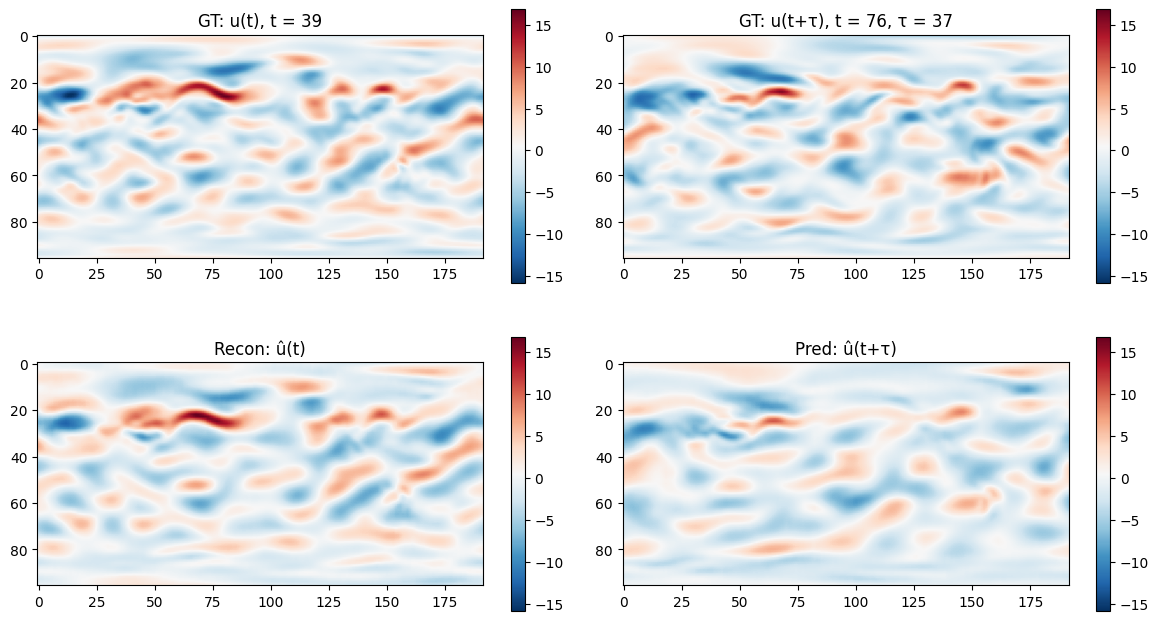

In [3]:
N_test, T, H, W = U_test_norm.shape
print("U_test_norm shape:", U_test_norm.shape)

# Convert normalization stats to plain floats for de-normalization
u_mean_val = float(u_mean)
u_std_val  = float(u_std)

# Sample a random trajectory and random (t0, tau)
traj_id = np.random.randint(0, N_test)      # which test trajectory
t0_0    = np.random.randint(0, T - 1)       # start time
tau_max = T - 1 - t0_0
tau_0   = np.random.randint(1, tau_max + 1) # ensure t0 + tau < T
t_tp0   = t0_0 + tau_0

print(f"Using traj_id={traj_id}, t0={t0_0}, tau={tau_0}, t0+tau={t_tp0}")

# Extract normalized fields: (H, W)
x_t      = U_test_norm[traj_id, t0_0]        # u(t)
x_t_tau  = U_test_norm[traj_id, t_tp0]       # u(t+tau)

# Add channel and batch dims -> (1, 1, H, W)
x_t      = x_t.unsqueeze(0).unsqueeze(0).to(device)
x_t_tau  = x_t_tau.unsqueeze(0).unsqueeze(0).to(device)

# tau_norm exactly as in training
tau_norm = torch.tensor([tau_0 / (T - 1)], dtype=torch.float32, device=device)  # (1,)

# Run model
model.eval()
with torch.no_grad():
    x_hat, x_hat_tau, mu, log_var, z, z_tau = model(x_t, tau_norm)

# Convert to numpy and de-normalize
x_t_0        = x_t[0, 0].detach().cpu().numpy()       * u_std_val + u_mean_val
x_tau_0      = x_t_tau[0, 0].detach().cpu().numpy()   * u_std_val + u_mean_val
x_hat_0      = x_hat[0, 0].detach().cpu().numpy()     * u_std_val + u_mean_val
x_hat_tau_0  = x_hat_tau[0, 0].detach().cpu().numpy() * u_std_val + u_mean_val

vmin = min(x_t_0.min(), x_tau_0.min(), x_hat_0.min(), x_hat_tau_0.min())
vmax = max(x_t_0.max(), x_tau_0.max(), x_hat_0.max(), x_hat_tau_0.max())

fig, axs = plt.subplots(2, 2, figsize=(12, 7))

im0 = axs[0, 0].imshow(x_t_0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axs[0, 0].set_title(f"GT: u(t), t = {t0_0}")
fig.colorbar(im0, ax=axs[0, 0], shrink=0.8)

im1 = axs[0, 1].imshow(x_tau_0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axs[0, 1].set_title(f"GT: u(t+τ), t = {t_tp0}, τ = {tau_0}")
fig.colorbar(im1, ax=axs[0, 1], shrink=0.8)

im2 = axs[1, 0].imshow(x_hat_0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axs[1, 0].set_title("Recon: û(t)")
fig.colorbar(im2, ax=axs[1, 0], shrink=0.8)

im3 = axs[1, 1].imshow(x_hat_tau_0, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axs[1, 1].set_title("Pred: û(t+τ)")
fig.colorbar(im3, ax=axs[1, 1], shrink=0.8)

plt.tight_layout()
plt.show()

In [4]:
N_test, T, H, W = U_test_norm.shape
print("U_test_norm shape:", U_test_norm.shape)

tau_max = T - 1  # = 87 for this dataset

# Define three equal bins for tau in [1, tau_max]
bin_size = tau_max // 3  # 87 // 3 = 29

bins = {
    "small":  (1, bin_size),                        # 1..29
    "medium": (bin_size + 1, 2 * bin_size),         # 30..58
    "large":  (2 * bin_size + 1, tau_max),          # 59..87
}

print("Tau bins:", bins)

def sample_tau_from_bin(lo, hi):
    """
    Sample a single integer tau in [lo, hi] using a normal distribution
    centered at the bin midpoint, with moderate spread.
    """
    mean = 0.5 * (lo + hi)
    std  = (hi - lo + 1) / 4.0  # not too sharp around center

    while True:
        val = int(np.round(np.random.normal(mean, std)))
        if lo <= val <= hi:
            return val

# MSE in normalized space
def mse_normalized(x_pred, x_true):
    return torch.mean((x_pred - x_true) ** 2).item()

n_samples_per_bin = 2500  # change if you want more/less

results = {}

with torch.no_grad():
    for bin_name, (tau_lo, tau_hi) in bins.items():
        sum_rec = 0.0
        sum_pred = 0.0
        count = 0

        for _ in range(n_samples_per_bin):
            # sample tau from this bin
            tau = sample_tau_from_bin(tau_lo, tau_hi)

            # sample random trajectory
            traj_id = np.random.randint(0, N_test)

            # sample t0 with constraint t0 + tau < T
            t0_max = T - 1 - tau
            if t0_max <= 0:
                continue
            t0 = np.random.randint(0, t0_max + 1)
            t_tp = t0 + tau

            # get normalized fields (H, W)
            x_t = U_test_norm[traj_id, t0]      # u(t)
            x_tp = U_test_norm[traj_id, t_tp]   # u(t+tau)

            # (1, 1, H, W)
            x_t = x_t.unsqueeze(0).unsqueeze(0).to(device)
            x_tp = x_tp.unsqueeze(0).unsqueeze(0).to(device)

            # tau_norm as in training
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device
            )

            # forward
            x_hat, x_hat_tau, mu, log_var, z, z_tau = model(x_t, tau_norm)

            # compute MSE in normalized space
            rec_mse = mse_normalized(x_hat, x_t)
            pred_mse = mse_normalized(x_hat_tau, x_tp)

            sum_rec += rec_mse
            sum_pred += pred_mse
            count += 1

        if count > 0:
            mean_rec = sum_rec / count
            mean_pred = sum_pred / count
        else:
            mean_rec = float("nan")
            mean_pred = float("nan")

        results[bin_name] = {
            "count": count,
            "mean_rec_mse": mean_rec,
            "mean_pred_mse": mean_pred,
        }

# Print metrics
print("\n=== MSE by tau bin (normalized units) ===")
for bin_name, stats in results.items():
    lo, hi = bins[bin_name]
    print(
        f"{bin_name:6s} tau∈[{lo:2d},{hi:2d}] | "
        f"samples={stats['count']:4d} | "
        f"rec MSE={stats['mean_rec_mse']:.4e} | "
        f"pred MSE={stats['mean_pred_mse']:.4e}"
    )

U_test_norm shape: torch.Size([700, 88, 96, 192])
Tau bins: {'small': (1, 29), 'medium': (30, 58), 'large': (59, 87)}

=== MSE by tau bin (normalized units) ===
small  tau∈[ 1,29] | samples=2500 | rec MSE=1.8258e-01 | pred MSE=3.1828e-01
medium tau∈[30,58] | samples=2500 | rec MSE=1.3330e-01 | pred MSE=3.7426e-01
large  tau∈[59,87] | samples=2478 | rec MSE=9.8722e-02 | pred MSE=4.3675e-01


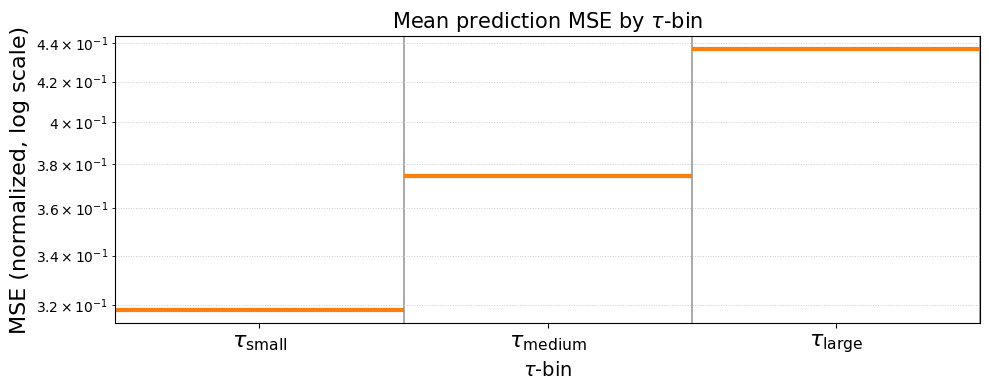

In [5]:
# Order of bins on the x-axis (left -> right)
bin_order = ["small", "medium", "large"]
x_labels = [r"$\tau_{\mathrm{small}}$", r"$\tau_{\mathrm{medium}}$", r"$\tau_{\mathrm{large}}$"]

# Define band boundaries and centers in x
x_lefts   = np.arange(len(bin_order))        # 0, 1, 2
x_rights  = x_lefts + 1                      # 1, 2, 3
x_centers = x_lefts + 0.5                    # 0.5, 1.5, 2.5

fig, ax = plt.subplots(figsize=(10, 4))

# Vertical lines to separate τ-zones
for x in range(len(bin_order) + 1):          # 0, 1, 2, 3
    ax.axvline(x, color="0.6", linewidth=1.2, zorder=0)

# Only prediction MSE as horizontal line segments spanning each τ-bin
for i, name in enumerate(bin_order):
    stats = results[name]
    y_pred = stats["mean_pred_mse"]

    ax.hlines(
        y_pred,
        x_lefts[i],
        x_rights[i],
        color="C1",
        linewidth=3,               # thicker line
        linestyle="-",
        label="Pred" if i == 0 else None,
    )

# Axis formatting
ax.set_xticks(x_centers)
ax.set_xticklabels(x_labels, fontsize=16)

ax.set_yscale("log")
ax.set_ylabel("MSE (normalized, log scale)", fontsize=16)
ax.set_xlabel(r"$\tau$-bin", fontsize=14)
ax.set_title("Mean prediction MSE by $\\tau$-bin", fontsize=15)

# Only keep horizontal grid lines (if you want them faint)
ax.yaxis.grid(True, which="both", linestyle=":", linewidth=0.7, color="0.8")
ax.xaxis.grid(False)

ax.set_xlim(0, len(bin_order))   # 0..3
#ax.legend(loc="upper right", fontsize=12)

plt.tight_layout()
#plt.savefig("tau_bin_pred_mse_horizontal.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
N_test, T, H, W = U_test_norm.shape
print("U_test_norm shape:", U_test_norm.shape)

traj_id = 682 #np.random.randint(U_test_norm.shape[0])  # fixed trajectory
tau_list = [15, 44, 85]  # small / medium / large jump

# time conversion: 20 days over (T-1) intervals
dt_hours = 20.0 * 24.0 / (T - 1)       # ≈ 5.5 h per step

u_mean_val = float(u_mean)
u_std_val  = float(u_std)

gt_snapshots = []
pred_snapshots = []
err_maps = []
rel_l2_list = []

model.eval()
with torch.no_grad():
    # initial condition at t0 = 0 (normalized)
    x0_norm = U_test_norm[traj_id, 0]                # (H, W)
    x0 = x0_norm.unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)

    for tau in tau_list:
        # ground–truth snapshot at t = tau (since t0=0)
        x_gt = U_test_norm[traj_id, tau].unsqueeze(0).unsqueeze(0).to(device)

        # normalized τ
        tau_norm = torch.tensor(
            [tau / (T - 1)],
            dtype=torch.float32,
            device=device
        )

        # forward pass (direct jump from t0 to t0+τ)
        x_hat, x_hat_tau, mu, log_var, z, z_tau = model(x0, tau_norm)

        # denormalize GT and prediction
        gt = x_gt[0, 0].cpu().numpy() * u_std_val + u_mean_val
        pred = x_hat_tau[0, 0].cpu().numpy() * u_std_val + u_mean_val

        # error map (absolute error, like in the paper’s plots)
        err = np.abs(pred - gt)

        # relative L2 error (per snapshot)
        rel_l2 = np.linalg.norm(pred - gt) / np.linalg.norm(gt)

        gt_snapshots.append(gt)
        pred_snapshots.append(pred)
        err_maps.append(err)
        rel_l2_list.append(rel_l2)

# shared color scale for GT & Pred
vmin = min(np.min(gt_snapshots), np.min(pred_snapshots))
vmax = max(np.max(gt_snapshots), np.max(pred_snapshots))

# color scale for error maps
err_vmax = max(np.max(e) for e in err_maps)

fig, axs = plt.subplots(3, len(tau_list), figsize=(16, 7), sharex=True, sharey=True)

for j, tau in enumerate(tau_list):
    hours = tau * dt_hours
    days = hours / 24.0

    gt = gt_snapshots[j]
    pred = pred_snapshots[j]
    err = err_maps[j]
    rel_l2 = rel_l2_list[j]

    # row 0: ground truth
    im_gt = axs[0, j].imshow(gt, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axs[0, j].set_title(f"T ≈ {hours:.0f} h (τ={tau}, ≈{days:.1f} d)", fontsize=15)

    # row 1: prediction
    im_pred = axs[1, j].imshow(pred, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    axs[1, j].set_title(f"Pred: τ={tau}", fontsize=12)

    # row 2: error (absolute)
    im_err = axs[2, j].imshow(err, cmap="Reds", vmin=0.0, vmax=err_vmax)
    axs[2, j].set_title(f"Error |û−u|, rel L²={rel_l2:.2e}", fontsize=15)

# row labels
axs[0, 0].set_ylabel("GT", fontsize=14)
axs[1, 0].set_ylabel("Pred", fontsize=14)
axs[2, 0].set_ylabel("Error", fontsize=14)

for ax_row in axs:
    for ax in ax_row:
        ax.set_xticks([])
        ax.set_yticks([])

# adjust layout to leave room for colorbars
plt.subplots_adjust(left=0.05, right=0.88, top=0.88, bottom=0.07, wspace=0.1, hspace=0.18)

# colorbar for GT/Pred
cax1 = fig.add_axes([0.90, 0.40, 0.015, 0.50])  # [left, bottom, width, height]
cb1 = fig.colorbar(im_pred, cax=cax1)
cb1.set_label("u (m/s)", fontsize=14)

# colorbar for Error
cax2 = fig.add_axes([0.90, 0.10, 0.015, 0.25])
cb2 = fig.colorbar(im_err, cax=cax2)
cb2.set_label("|û−u| (m/s)", fontsize=14)

fig.suptitle(f"Trajectory {traj_id}, initial condition at t₀=0", fontsize=18, y=0.95)

plt.savefig(f"traj{traj_id}_pred_gt_error_relL2.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# save initial condition figure as well
x0_denorm = x0_norm.cpu().numpy() * u_std_val + u_mean_val  # (H, W)

fig_ic, ax_ic = plt.subplots(figsize=(6, 3))
im_ic = ax_ic.imshow(x0_denorm, cmap="RdBu_r", vmin=vmin, vmax=vmax)
ax_ic.set_title(f"Trajectory {traj_id}, initial condition (t₀=0)", fontsize=16)
ax_ic.set_xticks([])
ax_ic.set_yticks([])

# smaller colorbar beside the IC
cax_ic = fig_ic.add_axes([0.88, 0.15, 0.03, 0.7])
cb_ic = fig_ic.colorbar(im_ic, cax=cax_ic)
cb_ic.set_label("u (m/s)", fontsize=12)

#plt.savefig(f"traj{traj_id}_initial_condition.png", dpi=300, bbox_inches="tight")
plt.close(fig_ic)

U_test_norm shape: torch.Size([700, 88, 96, 192])


## POD Analysis

U_test_norm shape: torch.Size([700, 88, 96, 192])
Using trajectory index: 682


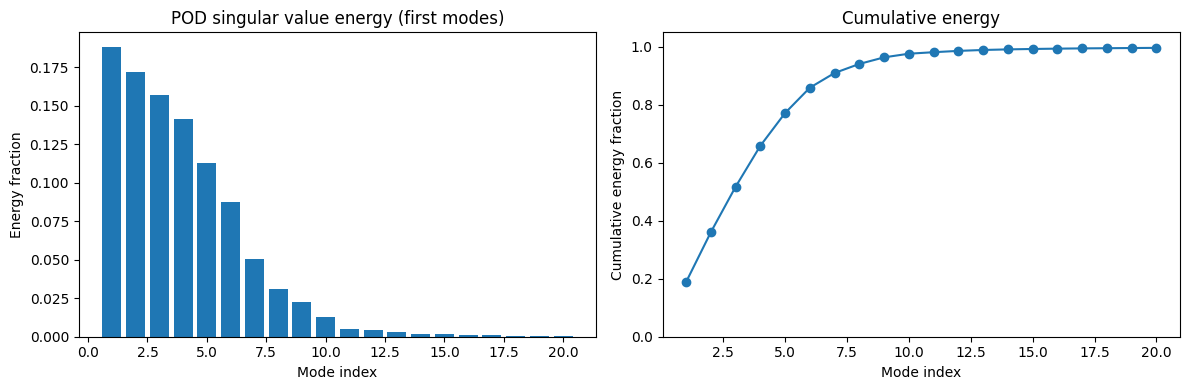

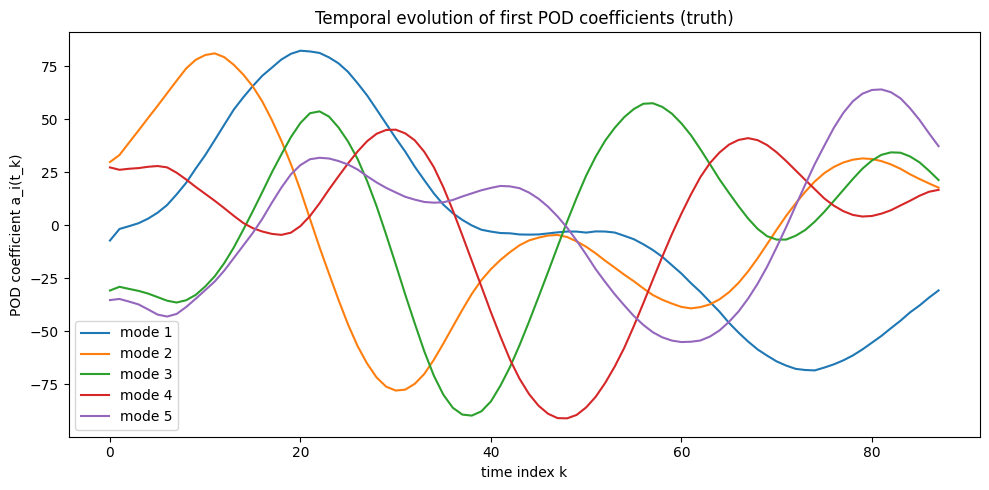

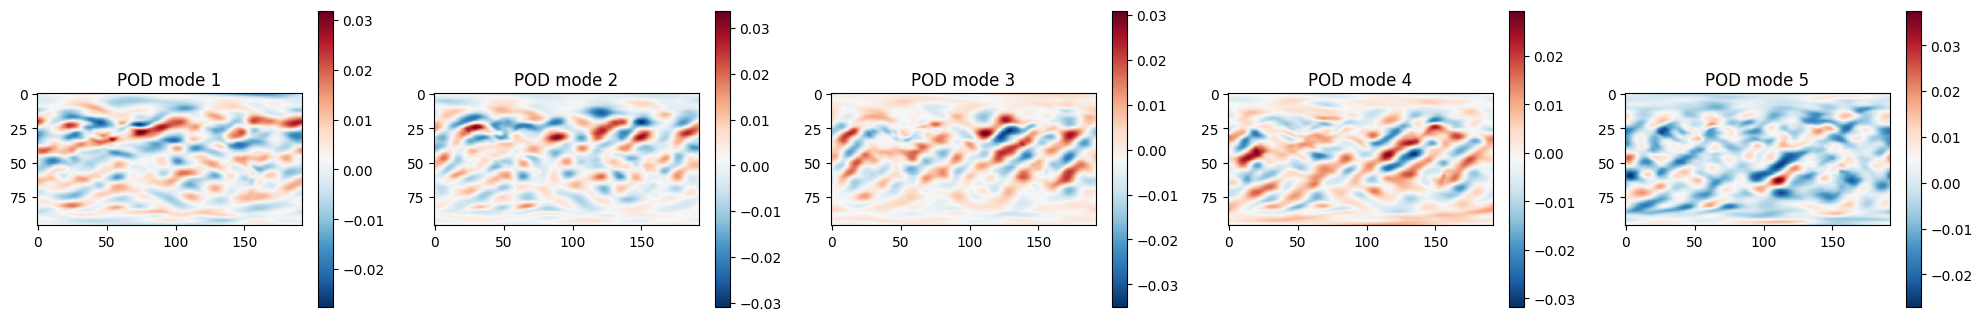

u_traj_pred shape: (88, 96, 192)
A_true shape: (88, 88) A_pred shape: (88, 88)


In [7]:
N_test, T, H, W = U_test_norm.shape
print("U_test_norm shape:", U_test_norm.shape)

print(f"Using trajectory index: {traj_id}")

# extract trajectory: (T, H, W) in normalized units
u_traj = U_test_norm[traj_id].cpu().numpy()   # shape (T, H, W)

# reshape to (M, T) with M = H*W
M = H * W
X = u_traj.reshape(T, M).T                    # (M, T)

# subtract temporal mean (standard POD practice)
X_mean = X.mean(axis=1, keepdims=True)       # (M, 1)
Xc = X - X_mean                              # centered data

# SVD: Xc = Phi * diag(S) * V^T
# Phi: spatial modes (M, r), S: singular values (r,), Vt: temporal right-singular vectors (r, T)
Phi, S, Vt = np.linalg.svd(Xc, full_matrices=False)

# POD time coefficients: A = diag(S) @ V^T  => (r, T)
A = np.diag(S) @ Vt                          # (r, T)

# energy content
energy = S**2
energy_frac = energy / energy.sum()
cum_energy = np.cumsum(energy_frac)

# number of modes to show
r_show = min(20, len(S))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# left: energy fraction of first r_show modes
axs[0].bar(np.arange(1, r_show + 1), energy_frac[:r_show])
axs[0].set_xlabel("Mode index")
axs[0].set_ylabel("Energy fraction")
axs[0].set_title("POD singular value energy (first modes)")

# right: cumulative energy
axs[1].plot(np.arange(1, r_show + 1), cum_energy[:r_show], marker="o")
axs[1].set_xlabel("Mode index")
axs[1].set_ylabel("Cumulative energy fraction")
axs[1].set_ylim(0, 1.05)
axs[1].set_title("Cumulative energy")

plt.tight_layout()
plt.show()

# time evolution of first few coefficients 
n_coeff_plot = min(5, A.shape[0])   # first 5 POD modes (or fewer if needed)
time = np.arange(T)

plt.figure(figsize=(10, 5))
for i in range(n_coeff_plot):
    plt.plot(time, A[i, :], label=f"mode {i+1}")
plt.xlabel("time index k")
plt.ylabel("POD coefficient a_i(t_k)")
plt.title("Temporal evolution of first POD coefficients (truth)")
plt.legend()
plt.tight_layout()
plt.show()

# visualize first few spatial modes
n_modes_vis = min(5, Phi.shape[1])

fig, axs = plt.subplots(1, n_modes_vis, figsize=(4 * n_modes_vis, 4))
if n_modes_vis == 1:
    axs = [axs]

for i in range(n_modes_vis):
    phi_i = Phi[:, i].reshape(H, W)
    im = axs[i].imshow(phi_i, cmap="RdBu_r")
    axs[i].set_title(f"POD mode {i+1}")
    plt.colorbar(im, ax=axs[i], shrink=0.8)

plt.tight_layout()
plt.show()


# non-autoregressive rollout with LEO (normalized space)
model.eval()

# use the same trajectory used for POD
u_traj_torch = U_test_norm[traj_id]          # (T, H, W) torch, normalized
T = u_traj_torch.shape[0]
H, W = u_traj_torch.shape[1], u_traj_torch.shape[2]
M = H * W

# anchor state at t0 = 0 (always use this as input)
x0 = u_traj_torch[0].unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)

pred_list = []
# first snapshot: match the IC exactly
pred_list.append(u_traj_torch[0].cpu().numpy())

with torch.no_grad():
    for k in range(1, T):
        # jump directly from t0 to t0 + k (in units of snapshot steps)
        tau = k
        tau_norm = torch.tensor(
            [tau / (T - 1)],      # <-- use same normalization as in training
            dtype=torch.float32,
            device=device,
        )

        x_hat, x_hat_tau, mu, log_var, z, z_tau = model(x0, tau_norm)
        pred_list.append(x_hat_tau[0, 0].cpu().numpy())

# predicted trajectory in normalized space: (T, H, W)
u_traj_pred = np.stack(pred_list, axis=0)
print("u_traj_pred shape:", u_traj_pred.shape)

# project both truth and prediction into POD basis
u_traj_truth = u_traj                          # (T, H, W) numpy, normalized

# flatten to (M, T)
X_truth = u_traj_truth.reshape(T, M).T         # (M, T)
X_pred  = u_traj_pred.reshape(T, M).T          # (M, T)

# center with the SAME mean used for POD
X_truth_c = X_truth - X_mean                   # (M, T)
X_pred_c  = X_pred  - X_mean                   # (M, T)

# project onto POD modes: A_true, A_pred are (r, T)
A_true = Phi.T @ X_truth_c
A_pred = Phi.T @ X_pred_c

print("A_true shape:", A_true.shape, "A_pred shape:", A_pred.shape)

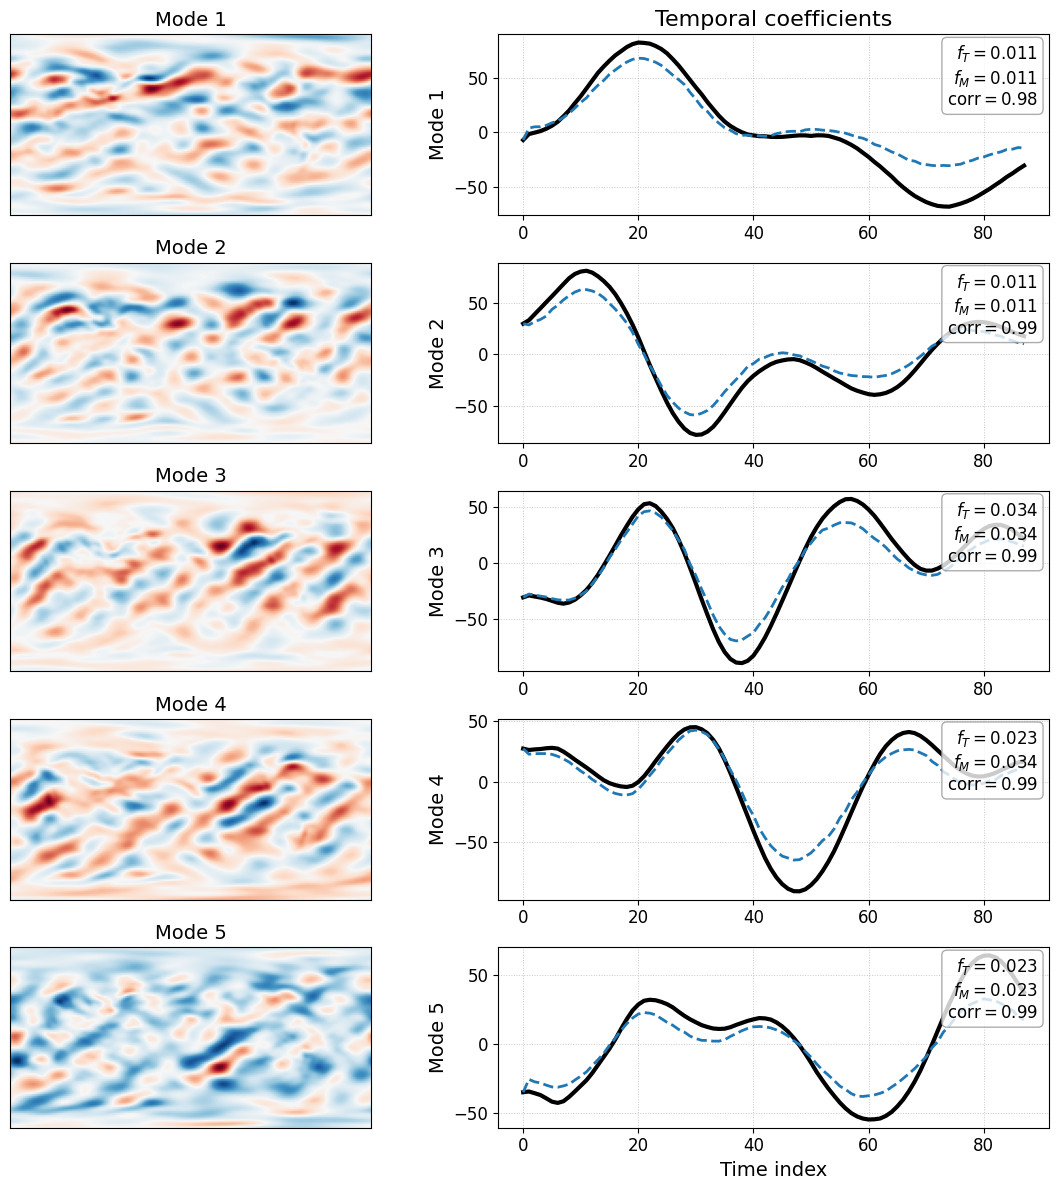

<Figure size 640x480 with 0 Axes>

In [8]:
# POD energy plots: bar + cumulative 
energy = S**2
energy_frac = energy / energy.sum()
cum_energy = np.cumsum(energy_frac)

r_show = min(20, len(S))

# (a) bar plot of energy fraction
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(np.arange(1, r_show + 1), energy_frac[:r_show])

ax.set_xlabel("Mode index", fontsize=14)
ax.set_ylabel("Energy fraction", fontsize=14)
ax.set_title(f"POD mode energy (trajectory {traj_id})", fontsize=16)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(f"pod_energy_traj{traj_id}.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# (b) cumulative energy
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, r_show + 1), cum_energy[:r_show], marker="o")

ax.set_xlabel("Mode index", fontsize=14)
ax.set_ylabel("Cumulative energy fraction", fontsize=14)
ax.set_title(f"Cumulative POD energy (trajectory {traj_id})", fontsize=16)
ax.set_ylim(0, 1.05)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(f"pod_cum_energy_traj{traj_id}.png", dpi=300, bbox_inches="tight")
plt.close(fig)


# Spatial modes + temporal evolution with freq & corr
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def corr(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

def fundamental_freq(a):
    """
    Estimate fundamental frequency (in cycles per time step)
    via the dominant peak of the magnitude of the rFFT,
    ignoring the zero-frequency (mean) component.
    """
    a_centered = a - np.mean(a)
    spec = np.fft.rfft(a_centered)
    mag = np.abs(spec)
    if mag.size <= 1:
        return np.nan
    mag[0] = 0.0  # ignore DC
    k = np.argmax(mag)
    return k / len(a)   # cycles per time step

n_modes = min(5, Phi.shape[1], A_true.shape[0])
time = np.arange(T)

fig, axes = plt.subplots(n_modes, 2, figsize=(12, 2.4 * n_modes))

if n_modes == 1:
    axes = np.array([axes])

for i in range(n_modes):
    # column 1: spatial POD mode 
    ax_img = axes[i, 0]
    phi_i = Phi[:, i].reshape(H, W)
    im = ax_img.imshow(phi_i, cmap="RdBu_r")
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    ax_img.set_title(f"Mode {i+1}", fontsize=14)

    # column 2: temporal coefficients
    ax_t = axes[i, 1]
    a_true = A_true[i, :]
    a_pred = A_pred[i, :]

    ax_t.plot(time, a_true, color="k", linewidth=3)
    ax_t.plot(time, a_pred, color="C0", linestyle="--", linewidth=2)

    ax_t.tick_params(axis="both", labelsize=12)
    ax_t.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)

    if i == 0:
        ax_t.set_title("Temporal coefficients", fontsize=16)
    if i == n_modes - 1:
        ax_t.set_xlabel("Time index", fontsize=14)

    ax_t.set_ylabel(f"Mode {i+1}", fontsize=14)

    # frequency + correlation annotation in top-right corner 
    f_true = fundamental_freq(a_true)
    f_model = fundamental_freq(a_pred)
    m_corr = corr(a_true, a_pred)

    text_str = (
        rf"$f_T={f_true:.3f}$" "\n"
        rf"$f_M={f_model:.3f}$" "\n"
        rf"$\mathrm{{corr}}={m_corr:.2f}$"
    )
    ax_t.text(
        0.98, 0.95, text_str,
        transform=ax_t.transAxes,
        ha="right", va="top",
        fontsize=12,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="0.6"),
    )

# no global legend anymore; black vs blue/dashed is clear
plt.tight_layout(rect=[0, 0, 0.97, 1.0])
plt.show()
plt.savefig(f"pod_spatial_temporal_with_freq_corr_traj{traj_id}.png",
            dpi=300, bbox_inches="tight")
plt.close(fig)

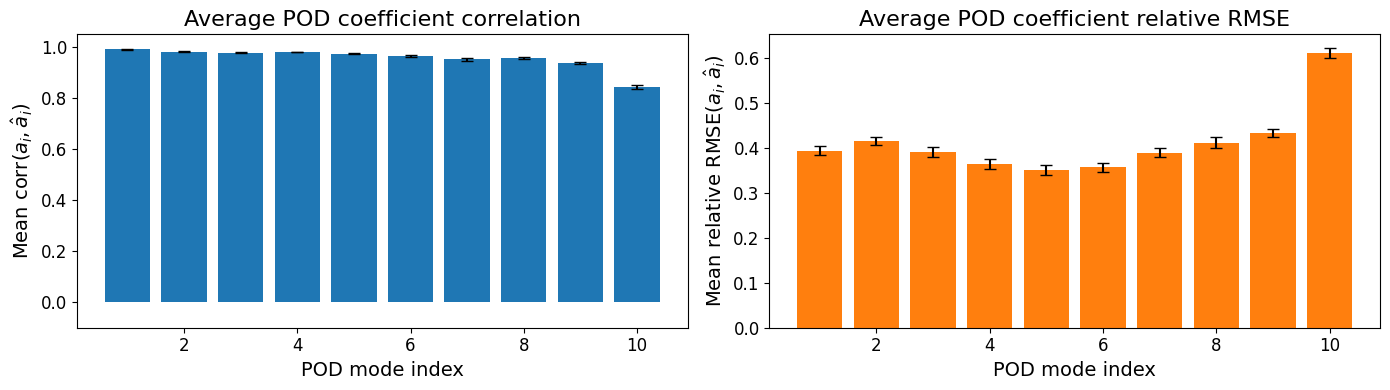

In [9]:
# helper
def corr(a, b):
    """Pearson correlation between two 1D arrays."""
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

def rel_rmse(a, b):
    """Relative RMSE: ||a-b||_2 / ||a||_2."""
    denom = np.linalg.norm(a)
    if denom == 0:
        return np.nan
    return np.linalg.norm(a - b) / denom


# settings
n_traj_to_sample = 50   # how many random test trajectories
max_modes        = 10   # compare first 10 POD modes

corr_list      = []
rel_rmse_list  = []

for n in range(n_traj_to_sample):
    #  pick a random test trajectory 
    traj_id = np.random.randint(0, N_test)
    u_traj_torch = U_test_norm[traj_id]          # (T, H, W) torch, normalized
    T = u_traj_torch.shape[0]
    H, W = u_traj_torch.shape[1], u_traj_torch.shape[2]
    M = H * W

    # truth trajectory (numpy)
    u_traj_truth = u_traj_torch.cpu().numpy()   # (T, H, W)
    X = u_traj_truth.reshape(T, M).T           # (M, T)

    # subtract temporal mean
    X_mean = X.mean(axis=1, keepdims=True)
    Xc = X - X_mean

    # POD from truth only
    Phi, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    A_true = np.diag(S) @ Vt                    # (r, T)

    # model trajectory: direct jumps from t0=0
    x0 = u_traj_torch[0].unsqueeze(0).unsqueeze(0).to(device)  # (1,1,H,W)

    pred_list = [u_traj_truth[0]]  # first snapshot = truth at t0
    model.eval()
    with torch.no_grad():
        for k in range(1, T):
            tau = k
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device,
            )
            x_hat, x_hat_tau, mu, log_var, z, z_tau = model(x0, tau_norm)
            pred_list.append(x_hat_tau[0, 0].cpu().numpy())

    u_traj_pred = np.stack(pred_list, axis=0)   # (T, H, W)

    # flatten and center both with same mean as POD
    X_truth = u_traj_truth.reshape(T, M).T      # (M, T)
    X_pred  = u_traj_pred.reshape(T, M).T       # (M, T)
    X_truth_c = X_truth - X_mean
    X_pred_c  = X_pred  - X_mean

    # project onto POD modes
    A_true_proj = Phi.T @ X_truth_c             # (r, T)
    A_pred_proj = Phi.T @ X_pred_c              # (r, T)

    r_compare = min(max_modes, A_true_proj.shape[0])

    corr_modes     = np.zeros(r_compare)
    rel_rmse_modes = np.zeros(r_compare)

    for i in range(r_compare):
        a_t = A_true_proj[i, :]
        a_p = A_pred_proj[i, :]
        corr_modes[i]     = corr(a_t, a_p)
        rel_rmse_modes[i] = rel_rmse(a_t, a_p)

    corr_list.append(corr_modes)
    rel_rmse_list.append(rel_rmse_modes)

# aggregate over trajectories
corr_arr     = np.vstack(corr_list)        # (n_traj, r_compare)
rel_rmse_arr = np.vstack(rel_rmse_list)    # (n_traj, r_compare)

n_eff = corr_arr.shape[0]

corr_mean = np.nanmean(corr_arr, axis=0)
corr_se   = np.nanstd(corr_arr, axis=0, ddof=1) / np.sqrt(n_eff)

rel_mean = np.nanmean(rel_rmse_arr, axis=0)
rel_se   = np.nanstd(rel_rmse_arr, axis=0, ddof=1) / np.sqrt(n_eff)

mode_indices = np.arange(1, r_compare + 1)

# plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# correlation
ax1.bar(mode_indices, corr_mean, yerr=corr_se, capsize=4)
ax1.set_xlabel("POD mode index", fontsize=14)
ax1.set_ylabel(r"Mean $\mathrm{corr}(a_i, \hat a_i)$", fontsize=14)
ax1.set_title("Average POD coefficient correlation", fontsize=16)
ax1.set_ylim(-0.1, 1.05)
ax1.tick_params(axis='both', labelsize=12)

# relative RMSE
ax2.bar(mode_indices, rel_mean, yerr=rel_se, capsize=4, color="tab:orange")
ax2.set_xlabel("POD mode index", fontsize=14)
ax2.set_ylabel(r"Mean relative RMSE$(a_i, \hat a_i)$", fontsize=14)
ax2.set_title("Average POD coefficient relative RMSE", fontsize=16)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig("pod_coeff_corr_relrmse_SE.png", dpi=300, bbox_inches="tight")
plt.show()

## Figure to show pred from intermediate state

In [10]:
# configuration for this figure
traj_id      = 518
time_indices = [0, 45, 61, 85]   # columns
anchors      = [0, 45, 61]       # rows: model from t=0, t=45, t=61

N_test, T, H, W = U_test_norm.shape
u_mean_val = float(u_mean)
u_std_val  = float(u_std)

# time conversion: 20 days over (T-1) intervals
dt_hours = 20.0 * 24.0 / (T - 1)   # ≈ 5–6 h per step

# ground-truth snapshots for this trajectory
gt_snaps = []   # list of (H, W)
for t_idx in time_indices:
    x_gt_norm = U_test_norm[traj_id, t_idx]              # (H, W) torch
    x_gt = x_gt_norm.cpu().numpy() * u_std_val + u_mean_val
    gt_snaps.append(x_gt)

# We'll use a global color scale based on all GT + model preds
all_vals = list(gt_snaps)

model.eval()
with torch.no_grad():
    for a in anchors:
        x_obs = U_test_norm[traj_id, a].unsqueeze(0).unsqueeze(0).to(device)
        for t_idx in time_indices:
            if t_idx < a:
                continue
            tau = t_idx - a
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device
            )
            _, x_hat_tau, _, _, _, _ = model(x_obs, tau_norm)
            pred = x_hat_tau[0, 0].cpu().numpy() * u_std_val + u_mean_val
            all_vals.append(pred)

vmin = min(arr.min() for arr in all_vals)
vmax = max(arr.max() for arr in all_vals)

def plot_row(fields, title_prefix, filename, anchor_t=None):
    """
    fields: list of (H, W) arrays (or None) in the order of time_indices.
    title_prefix: e.g. "GT" or "Model from t=0".
    anchor_t: if not None, mark that panel as the observed state.
    """
    n_cols = len(time_indices)
    fig, axs = plt.subplots(1, n_cols, figsize=(12, 3), sharex=True, sharey=True)

    for j, t_idx in enumerate(time_indices):
        ax = axs[j]
        field = fields[j]

        if field is None:
            ax.axis("off")
            continue

        im = ax.imshow(field, cmap="RdBu_r", vmin=vmin, vmax=vmax)

        hours = t_idx * dt_hours
        days = hours / 24.0

        if anchor_t is None:
            # GT row
            ax.set_title(
                f"{title_prefix}: t={t_idx}\n≈{hours:.0f} h, ≈{days:.1f} d",
                fontsize=11
            )
        else:
            if t_idx == anchor_t:
                ax.set_title(
                    f"{title_prefix}: t={t_idx} (obs)\n≈{hours:.0f} h, ≈{days:.1f} d",
                    fontsize=11
                )
            else:
                tau = t_idx - anchor_t
                ax.set_title(
                    f"{title_prefix}: t={t_idx} (τ={tau})\n≈{hours:.0f} h, ≈{days:.1f} d",
                    fontsize=11
                )

        ax.set_xticks([])
        ax.set_yticks([])

    # shorter colorbar on the right
    # [left, bottom, width, height] in figure coordinates
    cax = fig.add_axes([0.92, 0.28, 0.012, 0.4])  # height reduced from 0.7 -> 0.5
    cb = fig.colorbar(im, cax=cax)
    cb.set_label("u (m/s)", fontsize=11)

    plt.subplots_adjust(left=0.03, right=0.90, top=0.85, bottom=0.10, wspace=0.1)
    fig.suptitle(f"{title_prefix}, trajectory {traj_id}", fontsize=14, y=0.95)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close(fig)


# row 1: GT trajectory
plot_row(
    fields=gt_snaps,
    title_prefix="GT",
    filename="traj518_row_gt.png",
    anchor_t=None
)

# row 2: model predictions from t=0
pred_from_0 = []
model.eval()
with torch.no_grad():
    a = 0
    x_obs = U_test_norm[traj_id, a].unsqueeze(0).unsqueeze(0).to(device)
    for t_idx in time_indices:
        if t_idx < a:
            pred_from_0.append(None)
        else:
            tau = t_idx - a
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device
            )
            _, x_hat_tau, _, _, _, _ = model(x_obs, tau_norm)
            pred = x_hat_tau[0, 0].cpu().numpy() * u_std_val + u_mean_val
            pred_from_0.append(pred)

plot_row(
    fields=pred_from_0,
    title_prefix="Model from t=0",
    filename="traj518_row_model_from_t0.png",
    anchor_t=0
)

# row 3: model predictions from t=45
pred_from_45 = []
model.eval()
with torch.no_grad():
    a = 45
    x_obs = U_test_norm[traj_id, a].unsqueeze(0).unsqueeze(0).to(device)
    for t_idx in time_indices:
        if t_idx < a:
            pred_from_45.append(None)
        else:
            tau = t_idx - a
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device
            )
            _, x_hat_tau, _, _, _, _ = model(x_obs, tau_norm)
            pred = x_hat_tau[0, 0].cpu().numpy() * u_std_val + u_mean_val
            pred_from_45.append(pred)

plot_row(
    fields=pred_from_45,
    title_prefix="Model from t=45",
    filename="traj518_row_model_from_t45.png",
    anchor_t=45
)

# row 4: model predictions from t=61
pred_from_61 = []
model.eval()
with torch.no_grad():
    a = 61
    x_obs = U_test_norm[traj_id, a].unsqueeze(0).unsqueeze(0).to(device)
    for t_idx in time_indices:
        if t_idx < a:
            pred_from_61.append(None)
        else:
            tau = t_idx - a
            tau_norm = torch.tensor(
                [tau / (T - 1)],
                dtype=torch.float32,
                device=device
            )
            _, x_hat_tau, _, _, _, _ = model(x_obs, tau_norm)
            pred = x_hat_tau[0, 0].cpu().numpy() * u_std_val + u_mean_val
            pred_from_61.append(pred)

plot_row(
    fields=pred_from_61,
    title_prefix="Model from t=61",
    filename="traj518_row_model_from_t61.png",
    anchor_t=61
)